# 01 — Configuration 1 — Influence of temporal granularity (patch length P)

**Question.** Which patch size best represents the hourly dynamics of PV generation?

**Hypotheses.** A 24 h patch matches the solar cycle and yields "daily" tokens; a 12 h patch separates morning and afternoon; a 48 h patch reduces the number of tokens (cost) but merges two days. The stride between patches is P/2 (50 % overlap).

**Fixed parameters.** L = 168 h, CA-X channel handling (cross-channel attention + known future), H = 24 h.

**Protocol** (identical for every configuration — module `patchtst_pv`, section 8):
1. training on Train (2019–2021), early stopping on Val (01–09/2022), **5 seeds**;
2. accuracy on **every hourly origin of the Test set** (10/2022–05/2023): RMSE, MAE, nRMSE = RMSE / mean, R², MBE;
3. **robustness**: standard deviation over the seeds and 5 % Gaussian noise on the exogenous channels (rejected if ΔRMSE > 15 %);
4. **stability**: 30-day rolling forecast without re-training, drift = RMSE(D24–30) / RMSE(D1–7) (target < 1.2);
5. **efficiency**: inference time for one sample (< 100 ms) and weight size (< 50 MB);
6. **decision score** of `projet.md` (raw and normalised) and Diebold-Mariano tests against persistence and the 7-day mean.

> Trainings are cached (`cache/<configuration>/`): deleting the corresponding folder re-runs the full
> training from this notebook.

In [1]:
# --- Environment shared by all notebooks ------------------------------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patchtst_pv as m                # core module of the study (fully commented)
import figure_style as fs         # visual style of the paper's figures
fs.apply()
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)
import analysis as an, flowchart as fc, json, dataclasses
from nb_config import configs_for

## 1. Flowchart of the configuration

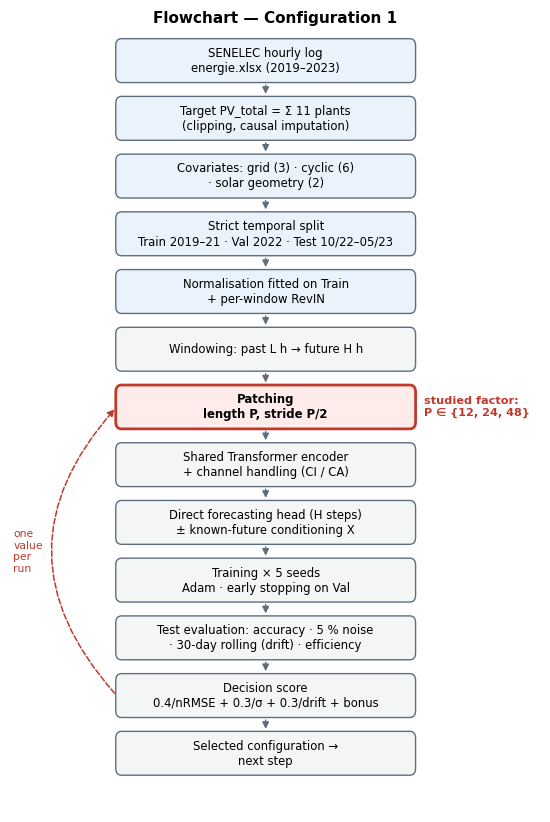

In [2]:
fc.draw(1, "Flowchart — Configuration 1", "flow_config1")

## 2. Configurations evaluated

In [3]:
ds = m.build_dataset()
configs = configs_for(1)
pd.DataFrame([dict(name=c.name(), P=c.P, L=c.L, H=c.H, channels=c.channel_mode, known_future=c.known_future,
                   physical_gate=c.physical_gate, n_patches=c.n_patches) for c in configs])

,name,P,L,H,channels,known_future,physical_gate,n_patches
0,PatchTST-CAX_P12_L168_H24,12,168,24,CA,True,False,27
1,PatchTST-CAX_P24_L168_H24,24,168,24,CA,True,False,13
2,PatchTST-CAX_P48_L168_H24,48,168,24,CA,True,False,6


## 3. Training and evaluation (5 seeds each)

In [4]:
results = [m.evaluate_configuration(c, ds) for c in configs]   # reads the cache if it exists
detail = pd.DataFrame([dict(configuration=r["name"], **{k: g[k] for k in
         ["seed", "epochs", "duration_s", "RMSE", "MAE", "nRMSE", "R2", "noise_degradation", "drift_7d", "drift_D30_D1"]})
         for r in results for g in r["per_seed"]])
detail

,configuration,seed,epochs,duration_s,RMSE,MAE,nRMSE,R2,noise_degradation,drift_7d,drift_D30_D1
0,PatchTST-CAX_P12_L168_H24,0,17,610.0148,9.1267,5.5268,0.2062,0.9733,0.0043,0.6037,0.5437
1,PatchTST-CAX_P12_L168_H24,1,25,877.0354,9.0266,5.2093,0.2039,0.9738,0.0047,0.5992,0.6601
2,PatchTST-CAX_P12_L168_H24,2,23,791.8121,9.0612,5.2093,0.2047,0.9736,0.0037,0.5825,0.5446
3,PatchTST-CAX_P12_L168_H24,3,25,855.0012,9.0015,5.1526,0.2034,0.9740,0.0049,0.5480,0.5791
4,PatchTST-CAX_P12_L168_H24,4,25,871.2810,8.8632,4.9452,0.2002,0.9748,0.0041,0.5864,0.5486
5,PatchTST-CAX_P24_L168_H24,0,24,391.5141,9.3091,5.8056,0.2103,0.9722,0.0065,0.6128,0.5928
6,PatchTST-CAX_P24_L168_H24,1,25,402.6207,8.9803,5.0191,0.2029,0.9741,0.0055,0.5406,0.5399
7,PatchTST-CAX_P24_L168_H24,2,25,401.3566,9.0836,5.2617,0.2052,0.9735,0.0056,0.5971,0.5800
8,PatchTST-CAX_P24_L168_H24,3,16,257.5751,9.2869,5.1899,0.2098,0.9723,0.0046,0.6088,0.4956
9,PatchTST-CAX_P24_L168_H24,4,25,402.3393,8.9811,5.2757,0.2029,0.9741,0.0057,0.5389,0.5125


## 4. Comparison table of the metrics (mean over 5 seeds) and naive baselines

In [5]:
table = m.comparison_table(results)
_, true0, orig0 = an.load_predictions(results[0]["name"])
refs = an.baseline_rows(ds, orig0, true0, configs[0].H) if len({c.H for c in configs}) == 1 else None
columns = ["configuration", "RMSE", "RMSE_std", "MAE", "nRMSE", "nRMSE_day", "R2", "MBE", "noise_degradation",
           "drift_D30_D1", "drift_7d", "inference_ms", "size_MB", "n_parameters", "score", "normalised_score", "rejected_noise"]
shown = pd.concat([table[columns], refs], ignore_index=True) if refs is not None else table[columns]
m.TABLES_DIR.mkdir(exist_ok=True)
shown.to_csv(m.TABLES_DIR / "table_config1.csv", index=False)
shown.round(4)

,configuration,RMSE,RMSE_std,MAE,nRMSE,nRMSE_day,R2,MBE,noise_degradation,drift_D30_D1,drift_7d,inference_ms,size_MB,n_parameters,score,normalised_score,rejected_noise
0,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,5.2086,0.2037,0.2146,0.9739,-0.0050,0.0044,0.5752,0.5839,2.9255,0.7265,186625.0,5.7561,0.8000,False
1,PatchTST-CAX_P24_L168_H24,9.1282,0.1608,5.3104,0.2062,0.2192,0.9732,0.0355,0.0056,0.5441,0.5796,2.3189,0.5346,136321.0,4.5228,0.2566,False
2,PatchTST-CAX_P48_L168_H24,9.2004,0.1030,5.2621,0.2079,0.2215,0.9728,-0.0493,0.0071,0.5240,0.5528,1.6185,0.4430,112321.0,5.5791,0.3736,False
3,Persistence D-1,10.3923,0.0000,4.9667,0.2348,NaN,0.9653,0.0030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7-day mean,10.8215,0.0000,5.3064,0.2445,NaN,0.9624,-0.0260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


*Reading the columns.* `RMSE_std`: standard deviation over the 5 seeds (robustness). `nRMSE_day`: nRMSE restricted to
daytime hours. `noise_degradation`: relative RMSE increase under 5 % noise on the exogenous channels. `drift_D30_D1`: raw
ratio of `projet.md` (sensitive to the cloudiness of two isolated days); `drift_7d`: smoothed ratio used in the score.
`score`: raw formula of `projet.md`; `normalised_score`: each criterion mapped to [0, 1] across the compared variants.

In [6]:
dm = an.dm_tests(ds, results)
dm.round(4)

,configuration,reference,skill_score,DM,p_value
0,PatchTST-CAX_P12_L168_H24,persistence,0.1314,-2.9661,0.0030
1,PatchTST-CAX_P12_L168_H24,7-day mean,0.1659,-3.0762,0.0021
2,PatchTST-CAX_P24_L168_H24,persistence,0.1259,-2.9013,0.0037
3,PatchTST-CAX_P24_L168_H24,7-day mean,0.1606,-2.9523,0.0032
4,PatchTST-CAX_P48_L168_H24,persistence,0.1153,-2.8035,0.0051
5,PatchTST-CAX_P48_L168_H24,7-day mean,0.1504,-2.9899,0.0028


## 5. Seed rosary and 30-day stability

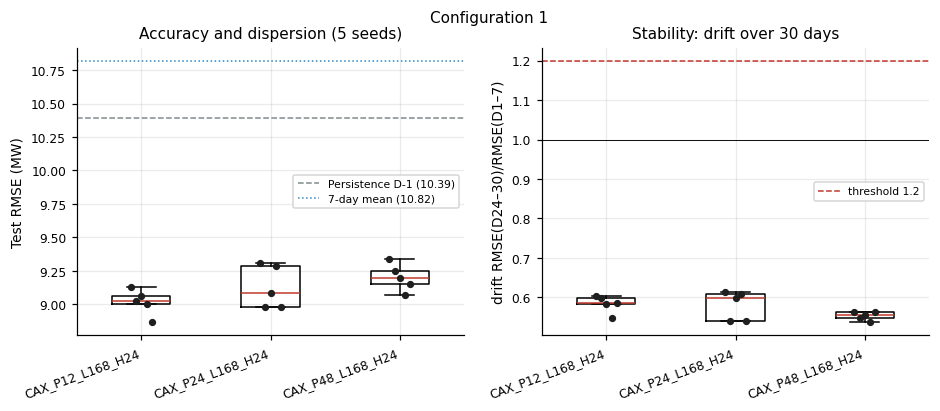

In [7]:
an.fig_rosary(results, ds, "fig_config1_rosary", "Configuration 1")

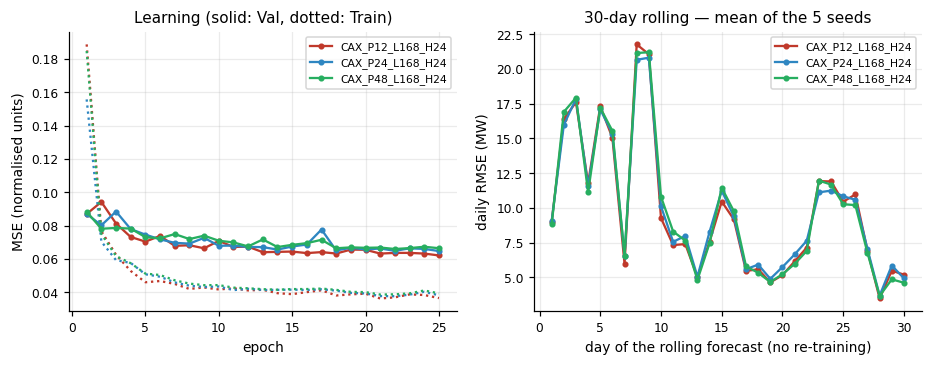

In [8]:
an.fig_learning_and_drift(results, "fig_config1_learning_drift")

## 6. Observed vs predicted series — best model of the configuration

Selected configuration: PatchTST-CAX_P12_L168_H24


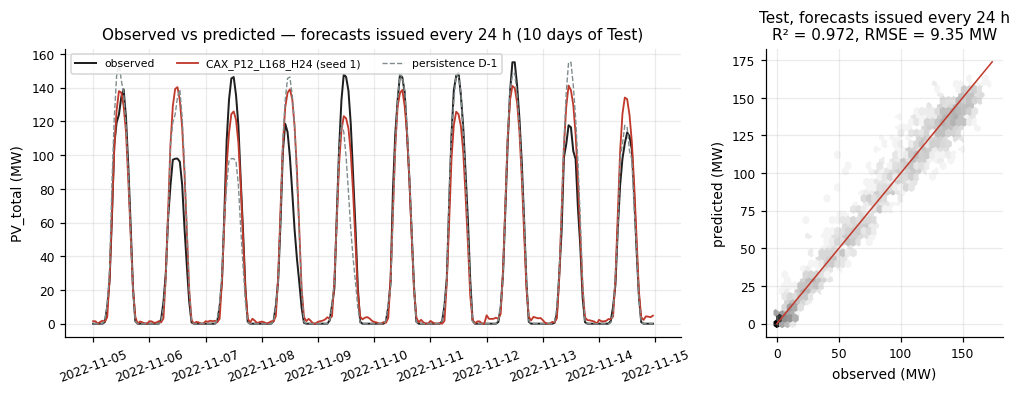

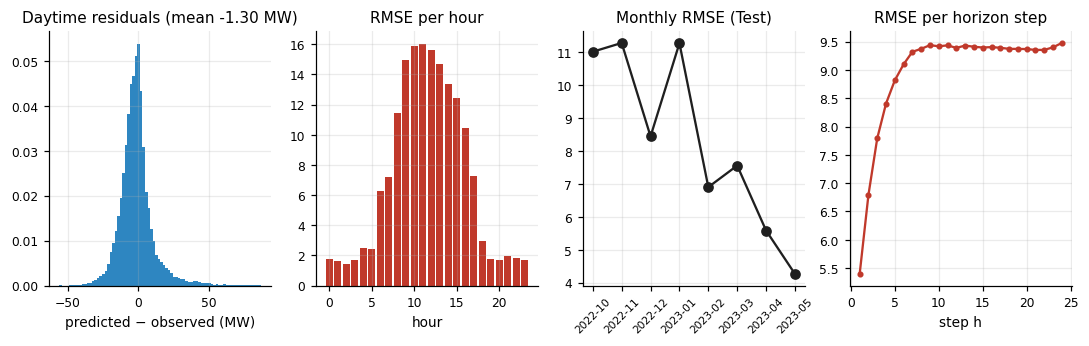

In [9]:
selected = an.selected_at("config1_patch")
print("Selected configuration:", selected)
res_selected = [r for r in results if r["name"] == selected][0]
an.fig_observed_vs_predicted(res_selected, ds, "fig_config1_observed_predicted")
an.fig_residuals(res_selected, ds, "fig_config1_residuals")

### Conclusion of configuration 1

**Selected configuration: `PatchTST-CAX_P12_L168_H24`** (normalised decision score = 0.800; raw score = 5.76).

- `PatchTST-CAX_P12_L168_H24`: RMSE = 9.02 ± 0.10 MW, nRMSE = 0.204, gain vs persistence = +13.2 %, degradation under noise = +0.4 %, 7-day drift = 0.58, inference = 2.9 ms, 186,625 parameters.
- `PatchTST-CAX_P24_L168_H24`: RMSE = 9.13 ± 0.16 MW, nRMSE = 0.206, gain vs persistence = +12.2 %, degradation under noise = +0.6 %, 7-day drift = 0.58, inference = 2.3 ms, 136,321 parameters.
- `PatchTST-CAX_P48_L168_H24`: RMSE = 9.20 ± 0.10 MW, nRMSE = 0.208, gain vs persistence = +11.5 %, degradation under noise = +0.7 %, 7-day drift = 0.55, inference = 1.6 ms, 112,321 parameters.

- RMSE gap between the best and the worst variant: 0.18 MW (2.0 %).
- All variants meet the robustness criterion (degradation < 15 %): yes; all meet the drift target < 1.2: yes; all meet the efficiency targets (< 100 ms, < 50 MB): yes.